In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [ ]:
col_names = ['EMG', 'Gesture']
df = pd.read_csv('Dataset_Claude_s_Code_fixed.csv', header=None, names=col_names)
print(df.shape)
print(df['Gesture'].value_counts())

(71992, 2)
Gesture
pinky&ring     8999
middle         8999
index          8999
thumb          8999
open hand      8999
fist           8999
bottle grip    8999
rest           8999
Name: count, dtype: int64


In [ ]:
df['Gesture'] = df['Gesture'].astype(str).str.strip()
print(df['Gesture'].unique())

['pinky&ring' 'middle' 'index' 'thumb' 'open hand' 'fist' 'bottle grip'
 'rest']


In [ ]:
scaler = StandardScaler()
df['Normalized_EMG'] = scaler.fit_transform(df[['EMG']])

In [ ]:
def extract_features(window):
    mav = np.mean(np.abs(window))
    rms = np.sqrt(np.mean(window**2))
    var = np.var(window)
    std = np.std(window)
    wl = np.sum(np.abs(np.diff(window)))
    zcr = np.sum(np.diff(np.sign(window)) != 0)
    ssc = np.sum(np.diff(np.sign(np.diff(window))) != 0)
    sk = skew(window)
    kt = kurtosis(window)
    iqr = np.percentile(window, 75) - np.percentile(window, 25)
    return [mav, rms, var, std, wl, zcr, ssc, sk, kt, iqr]

In [ ]:
WINDOW_SIZE = 30
OVERLAP = 25
STEP = WINDOW_SIZE - OVERLAP

features_list = []
labels_list = []

for gesture in df['Gesture'].unique():
    block = df[df['Gesture'] == gesture].reset_index(drop=True)
    signal = block['Normalized_EMG'].values.astype(float)

    for i in range(0, len(signal) - WINDOW_SIZE, STEP):
        window = signal[i:i+WINDOW_SIZE]
        features_list.append(extract_features(window))
        labels_list.append(gesture)

feature_names = ['MAV','RMS','Variance','Std','WL','ZCR','SSC','Skew','Kurtosis','IQR']
X = pd.DataFrame(features_list, columns=feature_names)
y = pd.Series(labels_list)

print(X.shape)
print(y.value_counts())

(14352, 10)
pinky&ring     1794
middle         1794
index          1794
thumb          1794
open hand      1794
fist           1794
bottle grip    1794
rest           1794
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
rf_model.fit(X_train, y_train)
print("Training complete")

Training complete


ACCURACY: 99.55%

              precision    recall  f1-score   support

 bottle grip       1.00      1.00      1.00       359
        fist       1.00      1.00      1.00       358
       index       0.98      0.99      0.98       359
      middle       1.00      1.00      1.00       359
   open hand       0.99      0.99      0.99       359
  pinky&ring       1.00      1.00      1.00       359
        rest       1.00      1.00      1.00       359
       thumb       1.00      0.98      0.99       359

    accuracy                           1.00      2871
   macro avg       1.00      1.00      1.00      2871
weighted avg       1.00      1.00      1.00      2871



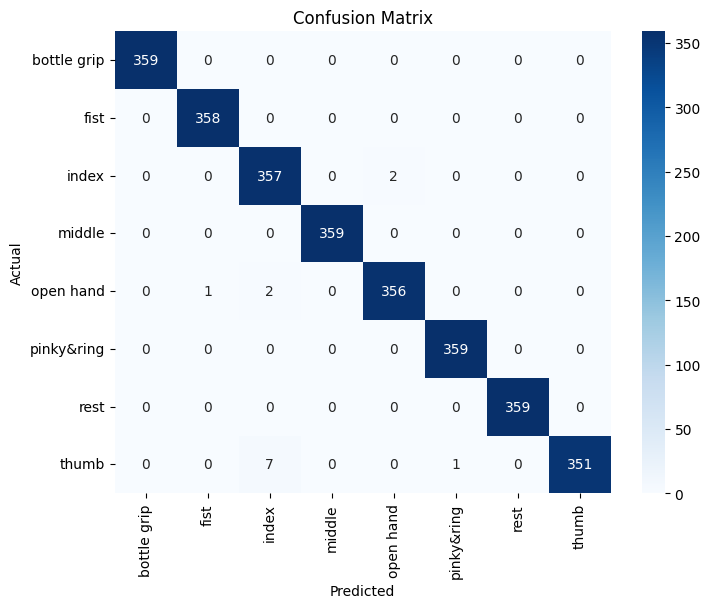

In [ ]:
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"ACCURACY: {accuracy * 100:.2f}%\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
joblib.dump(rf_model, 'ExoHand_RF_Model.joblib')
joblib.dump(scaler, 'ExoHand_Scaler.joblib')
print("Saved")

Saved
